Aqui, faremos a análise de qualidade dos dados já processados que transformamos anteriormente.

In [1]:
import pandas as pd

df = pd.read_csv('../dados/processados/internacoes_icsap_pr.csv.gz', sep=';',
                 dtype={'N_AIH': str, 'MUNIC_RES': str, 'DT_INTER': str, 'DIAG_PRINC': str})
print('Registros:', len(df))
print('Colunas:', len(df.columns))

Registros: 662730
Colunas: 10


Leitura do Dataframe e verificação se há a quantidade de registros que contamos anteriormente (662.730), então está ok.

In [2]:
nulos = df.isna().sum()
percentual = nulos / len(df) * 100
print(pd.DataFrame({'nulos': nulos, '%': percentual.round(2)}))

df['ano_mes'] = df['DT_INTER'].str[:6]
print('Meses distintos:', df['ano_mes'].nunique())

                 nulos    %
N_AIH                0  0.0
MUNIC_RES            0  0.0
DT_INTER             0  0.0
DIAG_PRINC           0  0.0
grupo_icsap          0  0.0
VAL_TOT              0  0.0
DIAS_PERM            0  0.0
flag_dias_zero       0  0.0
flag_dias_alto       0  0.0
flag_valor_zero      0  0.0
Meses distintos: 55


Nenhuma das 10 colunas tem valores ausentes (0%). A série tem os 55 meses esperados, de jan/2022 a jul/2026, depois da complementação dos 7 meses pelo FTP do DATASUS.

In [3]:
print('N_AIH repetidos:', df['N_AIH'].duplicated().sum())

N_AIH repetidos: 0


Nenhum N_AIH repetido, ou seja, cada uma das 662.730 linhas é uma internação diferente.

In [4]:
df['data'] = pd.to_datetime(df['DT_INTER'], format='%Y%m%d', errors='coerce')
print('Datas invalidas:', df['data'].isna().sum())
print('Primeira data:', df['data'].min())
print('Ultima data:', df['data'].max())

print('DIAS_PERM negativo:', (df['DIAS_PERM'] < 0).sum())
print('Flag dias zero:', df['flag_dias_zero'].sum())
print('Flag dias alto:', df['flag_dias_alto'].sum())
print('Flag valor zero:', df['flag_valor_zero'].sum())

cid_valido = df['DIAG_PRINC'].str.match(r'^[A-Z][0-9]{2}')
print('CID fora do formato:', (~cid_valido).sum())

Datas invalidas: 0
Primeira data: 2022-01-01 00:00:00
Ultima data: 2026-07-31 00:00:00
DIAS_PERM negativo: 0
Flag dias zero: 20528
Flag dias alto: 662
Flag valor zero: 2
CID fora do formato: 0


Todas as datas são válidas (de 01/01/2022 a 31/07/2026), não há dias de permanência negativos e todos os CIDs estão no formato esperado. Ficaram sinalizadas 20.528 internações com 0 dias (3,1%), 662 acima do limite de dias (0,1%) e 2 com valor pago zero.

In [5]:
municipios = pd.read_csv('../dados/processados/municipios_pr.csv', dtype=str)
municipio_ok = df['MUNIC_RES'].isin(municipios['codigo_datasus'])
print('MUNIC_RES fora da tabela do IBGE:', (~municipio_ok).sum())
print('Municipios presentes:', df['MUNIC_RES'].nunique(), 'de', len(municipios))

MUNIC_RES fora da tabela do IBGE: 0
Municipios presentes: 399 de 399


Todos os MUNIC_RES existem na tabela de municípios do IBGE, e os 399 municípios do Paraná aparecem na base.

ano_mes
202508    13977
202509    13644
202510    13810
202511    12877
202512    12473
202601    12773
202602    11653
202603    13694
202604    12620
202605    12289
202606    10662
202607     7017
dtype: int64


<Axes: title={'center': 'Internacoes ICSAP por mes'}, xlabel='ano_mes'>

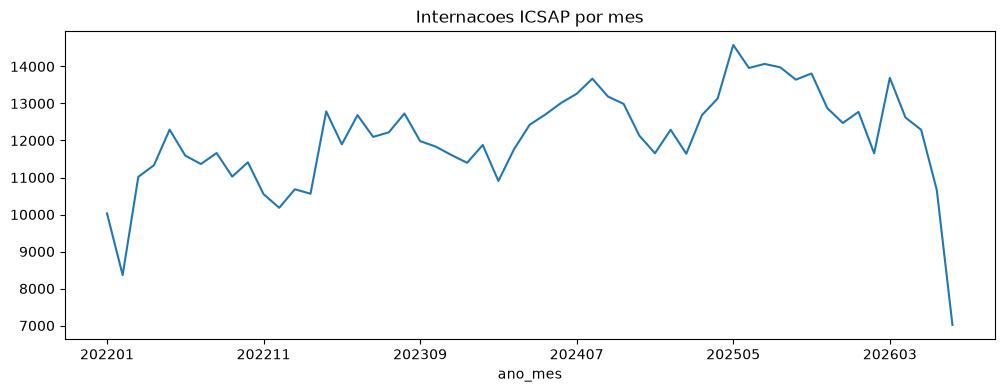

In [6]:
por_mes = df.groupby('ano_mes').size()
print(por_mes.tail(12))
por_mes.plot(figsize=(12, 4), title='Internacoes ICSAP por mes')

Os últimos meses caem bruscamente, podemos observar que junho e julho de 2026 ficam bem abaixo do patamar dos meses anteriores. Isso indica dado ainda chegando ao DATASUS, porque internações recentes podem não ter sido processadas. Esses meses devem ser tratados como provisórios e devemos pensar nisso para a futura modelagem.